
# ME72: Maestría en Métodos Cuantitativos para la Gestión y Análisis de Datos
## M72109: Analisis de datos no estructurados
```
Universidad de Buenos Aires - Facultad de Ciencias Economicas (UBA-FCE)
Año: 2026
Profesor: Facundo Santiago, Javier Ignacio Garcia Fronti
Alumno: Mauricio Cristaldo
```


# Desafio de memorabilidad: NLP

Como trabajo final para la materia, les proponemos resolver un desafio de memorabilidad de un video, el cual requerirá de utilizar todos los conceptos que revisamos en la materia **al mismo tiempo**: imagenes, audio y texto.

## ¿De que se trata el desafío?

Esta tarea se centra en el problema de predecir qué tan memorable es un video para un espectador. Definiremos a un video como memorable como la probabilidad de que se recuerde tal video luego de un lapso de tiempo determinado.

Recibirán un extenso conjunto de datos de videos que van acompañados de anotaciones memorables, así como predictores (features) extraídos previamente que reflejan distintos preprocesamientos de los videos para que la tarea le resulte más sencilla. Las etiquetas (labels) se ha recopilado a través de pruebas de reconocimiento y, por lo tanto, es el resultado de una medición objetiva del rendimiento de la memoria.

<img src='https://raw.githubusercontent.com/santiagxf/M72109/master/Desafio/Docs/memorability.PNG' width=600 />

*Creditos del desafio original:*

http://www.multimediaeval.org/mediaeval2019/memorability/

Mihai Gabriel Constantin, University Politehnica of Bucharest, Romania
Bogdan Ionescu, University Politehnica of Bucharest, Romania
Claire-Hélène Demarty, Technicolor, France
Quang-Khanh-Ngoc Duong, Technicolor, France
Xavier Alameda-Pineda, INRIA, France
Mats Sjöberg, CSC, Finland

Para mas información sobre esta tarea, puede revisar [Overview of The MediaEval 2021 Predicting Media Memorability Task](https://arxiv.org/abs/2112.05982)

## Direcciones

Deberán entrenar modelos de aprendizaje automático capaces de inferir la memorabilidad de video a partir del contenido **de texto**.

Utilizando estos datos, deberán evaluar la performance del modelo utilizando un set de datos de evaluación. Los modelos se evaluarán a través de métricas de evaluación estándar utilizadas en las tareas de clasificación y regresión (dependiendo del tipo de desafío que elijan).

Cuentan con 2 tipos de anotaciones para cada uno de los fragmentos de video disponibles:
 - **memorability_score:** Representa el puntaje de memorabilidad de la secuencia en particular, desde 0 a 1. Valores más grandes son mejores.
 - **memorable:** Variable categórica que representa si un video es memorable o no. Un video con `memorability_score` superior a `0.5` es marcado como memorable (`1`), sino es marcado como no memorable (`0`)

 > Note que aquí nuestras muestras son "secuencias" de determinadas películas. En total dispone de 660 secuencias con el nombre `sequence_name`. El mismo nombre se generó automáticamente concatenando el nombre de la pelicula a la que pertenece la secuencia (movie_name), seguido del segundo en el que comienza la secuencia, seguido del segundo en el que termina, seguido de un numero que indica el número de secuencia. Por ejemplo, la secuencia `127_hours_2000_2010_1` es un fragmento de la pelicula "127 hours", que va desde el segundo 2000 (00:33:20 hrs.) al segundo 2010 (00:33:30 hrs.) y es el fragmento número 1. Esta información es totalmente irrelevante para el problema de memorabilidad pero **el nombre de la secuencia (`sequence_name`) será su clave primeria para vincular los diferentes conjuntos de datos.**

### Entrega

Debera entregar:


2. El archivo de Colab con la solución propuesta.
3. El codigo debe:
    1. Entrenar o diseñar 1 modelo de aprendizaje automático basado en técnicas de NLP.
    2. Poder ser ejecutable de arriba a abajo.
    3. Poder ser ejecutado sin errores.
    4. Estar claramente documentado con el paso a paso de porque realiza lo que realiza.
    5. Utilizar solo técnicas vistas en la materia.
    6. No contener código no utilizado.

4. Subir el mismo dentro de la tarea correspondiente.


## Preparación del ambiente

### NLP

In [1]:
!wget https://raw.githubusercontent.com/santiagxf/M72109/master/m72109/nlp/normalization.py \
    --quiet --no-clobber --directory-prefix ./m72109/nlp/
!wget https://raw.githubusercontent.com/santiagxf/M72109/master/m72109/nlp/transformation.py \
    --quiet --no-clobber --directory-prefix ./m72109/nlp/
!wget https://raw.githubusercontent.com/santiagxf/M72109/master/docs/nlp/neural/sequences-word2vec.txt \
    --quiet --no-clobber

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
!pip install -r sequences-word2vec.txt --quiet
!pip install datasets --quiet
!pip install transformers --quiet
!pip install unidecode --quiet
!python -m spacy download es_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-api 1.38.0 requires importlib-metadata<8.8.0,>=6.0, but you have importlib-metadata 4.13.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 79.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Sets de datos

Descargamos el set de datos:

In [4]:
!wget https://raw.githubusercontent.com/santiagxf/M72109/refs/heads/master/Desafio/Data/ground_truth.csv --directory-prefix ./Data/ --quiet --no-clobber
!wget https://raw.githubusercontent.com/santiagxf/M72109/refs/heads/master/Desafio/Data/Features/caption_features.csv --directory-prefix ./Data/Features/ --quiet --no-clobber

Cargamos el set de datos:

In [5]:
import pandas as pd

labels = pd.read_csv('Data/ground_truth.csv')
cc = pd.read_csv('Data/Features/caption_features.csv', names=['sequence_name','cc'], header=0)

Los conjuntos de datos utilizados en este desafío son los siguientes:

*   `ground_truth.csv`: Contiene la verdad fundamental para el problema de clasificación. Este archivo incluye información sobre segmentos de video (`movie_name`, `start(sec)`, `end(sec)`) y su correspondiente puntuación de memorabilidad (`memorability_score`). **Aunque contiene varias columnas, para el problema de clasificación que abordaremos, la columna clave es `memorable`, que indica la probabilidad de que una persona recuerde el video.**
*   `caption_features.csv`: Contiene las características de las "captions" (descripciones textuales) asociadas a cada segmento de video. Cada segmento de video se identifica por `sequence_name` y cuenta con una descripción en la columna `cc`.

**Para proceder con el análisis, será necesario combinar estas etiquetas (`ground_truth.csv`) con las características (`caption_features.csv`).**

----

# Solución de Modelo basado en encoders



En este trabajo abordamos el desafío de predecir la memorabilidad de secuencias de video utilizando únicamente información de texto, específicamente las *captions* que son descripciones asociadas a cada fragmento. En consecuencia se busca responder si la descripcion de la escena es sufuciente para hacerla memorable o no.

Siguiendo el programa de la materia se propone una solución utilizando el Modelo basado en encodres Word2Vec.

Para ello se realizaron las siguientes tareas:

0. Obtencón las bibliotecas necesarias para el codigo

1. Preprocesamiento que incluye:
  * Normlizacion con tweetokinezer
  * Armado de la variable de claisificacion "memorable"

2. Vectorizacion de palabras
  * Visualizacion de densidad de palabras
  * cut 1200 caracteres
  * Padding

3. Armado de conjunto de entrenamieto y test

4. Construccion del modelo con las siguientes caracteristicas:
  * Secuencial,
  * Denso (Embbeddings 100),
  * LSTM: Long Short-Term Memory layer

5. Entreamineto 20 epocas

6. Resultados del modelo.



```
# Visualizacion del DF original
```





In [6]:
cc.head()

,sequence_name,cc
0,127_hours_2000_2010_1,a man in a suit and tie standing in front of a...
1,127_hours_2182_2192_5,a man holding a toothbrush in his mouth. a wom...
2,127_hours_271_281_1,a view of a mountain range from a plane. a fir...
3,127_hours_285_295_2,a person is flying a kite in the sky. a person...
4,127_hours_328_338_3,a person holding a cell phone in their hand. a...


## 0. Bibliotecas

In [7]:
!pip install gensim


In [8]:
#import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, Dense, LSTM, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer

from m72109.nlp.transformation import PadSequenceTransformer
from gensim.models import Word2Vec
from m72109.nlp.normalization import TextNormalizer
from nltk.tokenize.casual import TweetTokenizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from unidecode import unidecode
import spacy


## 1. Preprocesamiento


In [9]:
data = labels.merge(cc, on="sequence_name", how="inner")
data["memorable"] = (data["memorability_score"] > 0.5).astype(int)
data = data[[ 'cc', 'memorable']]
data.head()


,cc,memorable
0,a man in a suit and tie standing in front of a...,1
1,a man holding a toothbrush in his mouth. a wom...,0
2,a view of a mountain range from a plane. a fir...,1
3,a person is flying a kite in the sky. a person...,1
4,a person holding a cell phone in their hand. a...,1


In [10]:
X_raw = data["cc"].astype(str)
y = data["memorable"]


In [11]:
normalizer = TextNormalizer(
    tokenizer=TweetTokenizer(),
    language='english',
    lemmatize=False,      #Desactivado dado que no es necesario para word2vec
    strip_stopwords=False, #Desactivado
    strip_urls=True,
    strip_accents=True,
    preserve_case=False,
    return_tokens=True
)

X_tokens = normalizer.transform(X_raw)

100%|██████████| 660/660 [00:13<00:00, 50.30it/s]


## 2. Vectorización de las palabras

In [12]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_tokens)

In [13]:
vocab_size = tokenizer.num_words + 1
print('El tamaño del vocabulario es: %d' % vocab_size)

El tamaño del vocabulario es: 10001


In [14]:
list(tokenizer.word_index.items())[:20]

[('a', 1),
 ('.', 2),
 ('in', 3),
 ('of', 4),
 ('is', 5),
 ('man', 6),
 ('woman', 7),
 ('holding', 8),
 ('cell', 9),
 ('standing', 10),
 ('phone', 11),
 ('and', 12),
 ('on', 13),
 ('hand', 14),
 ('with', 15),
 ('front', 16),
 ('the', 17),
 ('person', 18),
 ('sitting', 19),
 ('tie', 20)]

In [15]:
#Se aplica la transformación para pasar de palabras a indices:
input_data= tokenizer.texts_to_sequences(X_tokens)

* Visualizacion de densidad de palabras

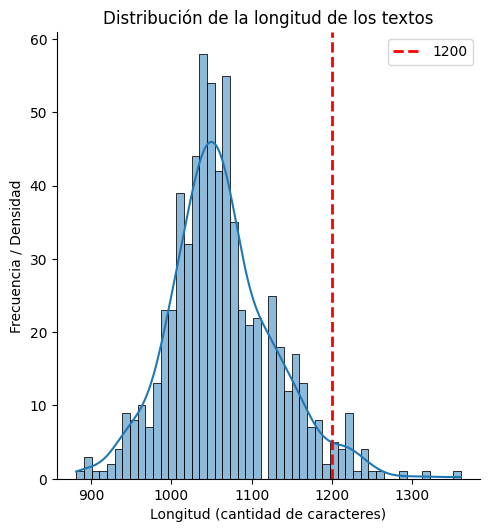

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

data_lens = [len(n) for n in input_data]

sns.displot(data_lens, kde=True, bins=50)   # kde=True para ver la curva de densidad

# Agregar línea vertical roja en 1200
plt.axvline(x=1200, color='red', linestyle='--', linewidth=2, label='1200')

# Mejorar el gráfico
plt.title('Distribución de la longitud de los textos')
plt.xlabel('Longitud (cantidad de caracteres)')
plt.ylabel('Frecuencia / Densidad')
plt.legend()

plt.show()

`Se visualiza un corte por mayor a 1200 caracteres como valores outliers`

In [17]:
max_seq_len = 120

* Procedimiento de padder o rellenado

In [18]:
padder = PadSequenceTransformer(max_len=max_seq_len)

In [19]:
input_data_padded = padder.transform(input_data)

In [20]:
input_data_np =  np.array(input_data_padded).astype('int32')

## 3. Creando conjuntos de entrenamiento y validación

In [21]:
from sklearn.model_selection import train_test_split

idx_train, idx_test = train_test_split(range(len(input_data_np)),
                                       test_size=0.33,
                                       stratify=data['memorable'])

Necesitamos la variable de salida codificada también en forma de indices:

In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(data["memorable"])
number_classes = len(label_encoder.classes_)

Creamos los conjuntos de datos:

In [23]:
X_train = np.array(input_data_np[idx_train]).astype('int32')
y_train = np.array(label_encoder.transform(data["memorable"][idx_train]))

X_test = np.array(input_data_np[idx_test]).astype('int32')
y_test = np.array(label_encoder.transform(data["memorable"][idx_test]))

In [24]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (442, 120)
Testing: (218, 120)


## 4. Construcción del modelo

Para construir este modelo, se utiliza TensorFlow. En particular la API de Keras que permite componer modelos de redes neuronales como una secuencia de pasos o capas que se conectan en una dirección.

Usando los siguientes tipos de capas:
 *  **Embedding:** Esta capa transforma vectores que representan indices dentro de una matriz en representaciones vectoriales densas. Básicamente en este caso nos resolverá la busqueda de las representaciones vectoriales las nuestras palabras. **Intentaremos aprender embdeddings de tamaño 100**
 * **SpatialDropout1D:** Este tipo de capas ayudan a promover la independencia entre filtros (feature maps). Funciona en forma analoga a Dropout pero en lugar de desconectar elementos individuales, desconecta el filtro completo.
 * **LSTM:** Long Short-Term Memory layer - Hochreiter 1997
 * **Dense:** Una típica capa de una red neuronal completamente conectada (fully connected)

Algunos detalles para notar:
 * *loss='sparse_categorical_crossentropy'*, este problema de clasificación (crossentropy) de más de una clase (categorical). Sin embargo, nuestro output produce probabilidades de cada una de las clases posibles (7) en forma one-hot encoding.
 * *metrics=['accuracy']*: Si bien nuestra metrica es accuracy, Keras hará un promedio ponderado del accuracy de cada clase. Este es el comportamiento por defecto.

In [25]:
emdedding_size = 100

In [26]:
model = Sequential([
    Embedding(input_dim=vocab_size,
              input_length=max_seq_len,
              output_dim=emdedding_size,
              mask_zero=True),
    SpatialDropout1D(0.2),
    LSTM(emdedding_size),
    Dense(number_classes, activation="softmax", name="output")
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=["accuracy"])

Podemos inspeccionar el modelo:

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento

Entrenamos nuestro modelo

In [28]:
history = model.fit(X_train,
                    y_train,
                    batch_size=124,
                    epochs=20,
                    validation_data=(X_test, y_test))

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 508ms/step - accuracy: 0.5588 - loss: 0.6899 - val_accuracy: 0.5596 - val_loss: 0.6872
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 435ms/step - accuracy: 0.5588 - loss: 0.6834 - val_accuracy: 0.5596 - val_loss: 0.6850
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step - accuracy: 0.5588 - loss: 0.6798 - val_accuracy: 0.5596 - val_loss: 0.6842
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 339ms/step - accuracy: 0.5588 - loss: 0.6726 - val_accuracy: 0.5596 - val_loss: 0.6834
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5588 - loss: 0.6652 - val_accuracy: 0.5550 - val_loss: 0.6818
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 714ms/step - accuracy: 0.5701 - loss: 0.6525 - val_accuracy: 0.5550 - val_loss: 0.6786
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 370ms/step - accuracy: 0.5928 - loss: 0.6352 - val_accuracy: 0.5367 - val_loss: 0.6718
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.6516 - loss: 0.6210 - val_accuracy: 0.5275 - val_loss: 0.

## 6. Evalución de los resultados

Probamos su performance utilizando el test set

In [29]:
predictions = model.predict(X_test).argmax(axis=-1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step


In [30]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions,
    target_names=[str(c) for c in label_encoder.classes_]
))

              precision    recall  f1-score   support

           0       0.64      0.46      0.53       122
           1       0.49      0.67      0.57        96

    accuracy                           0.55       218
   macro avg       0.56      0.56      0.55       218
weighted avg       0.57      0.55      0.55       218



`Respuesta: `

El modelo propuesto —basado en una arquitectura LSTM alimentada por embeddings distribuidos de 100 dimensiones— muestra que la descripción textual de las escenas no constituye una señal suficientemente informativa para predecir con precisión su memorabilidad.

Aunque el modelo LSTM logra recuperar un 67% de los casos realmente memorables, su precisión es baja y la exactitud global apenas supera el 55% (Accuracy).

En respuesta el texto, bajo este modelo, ayuda pero no es suficiente para para capturar la totalidad del fenomeno de la memorabilidad. Por lo tanto se justifica la exploración de alternativas como Transformers, embeddings preentrenados de mayor riqueza semántica o enfoques multimodales que integren información visual.